
Dataset Loaded Successfully
    job_id                 job_title  salary_usd salary_currency  \
0  AI00001            Data Scientist      219728             USD   
1  AI00002                Head of AI      230237             JPY   
2  AI00003             Data Engineer      128890             EUR   
3  AI00004  Computer Vision Engineer       96349             USD   
4  AI00005         Robotics Engineer       63065             EUR   

   salary_local experience_level employment_type company_location  \
0        219728               EX              PT           Sweden   
1      25326070               EX              PT            Japan   
2        109557               EX              CT          Germany   
3         96349               MI              FL          Finland   
4         53605               EN              FT           France   

  company_size employee_residence  remote_ratio  \
0            M             Sweden             0   
1            L              Japan            

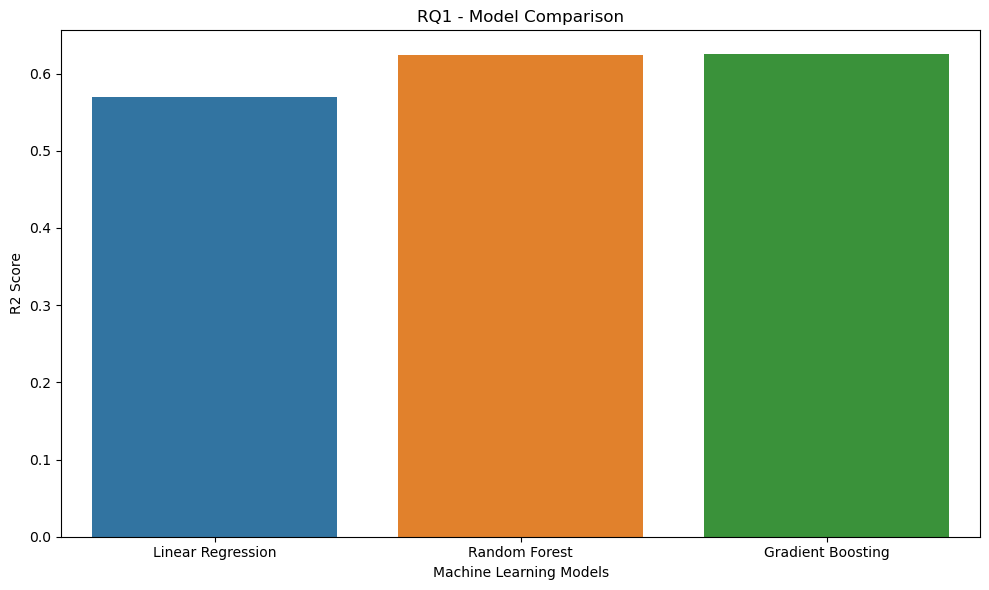

Figure saved in models folder


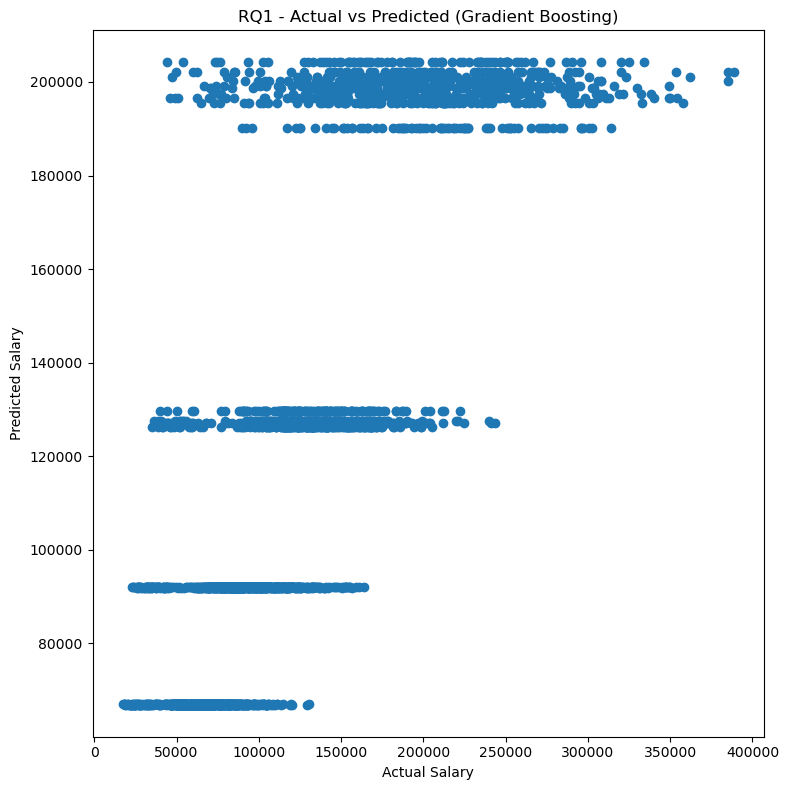

Figure saved in models folder


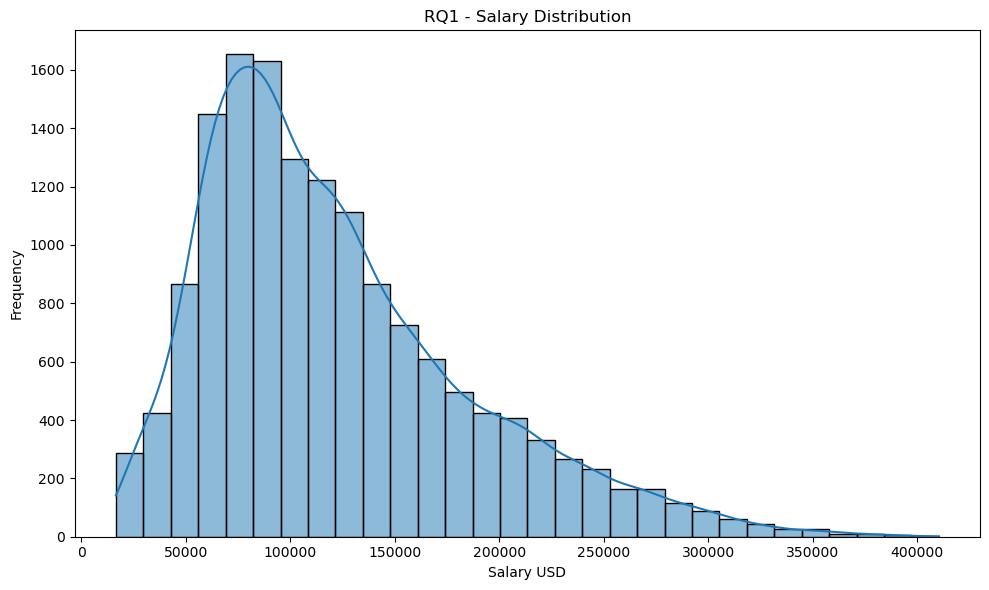

Figure saved in models folder


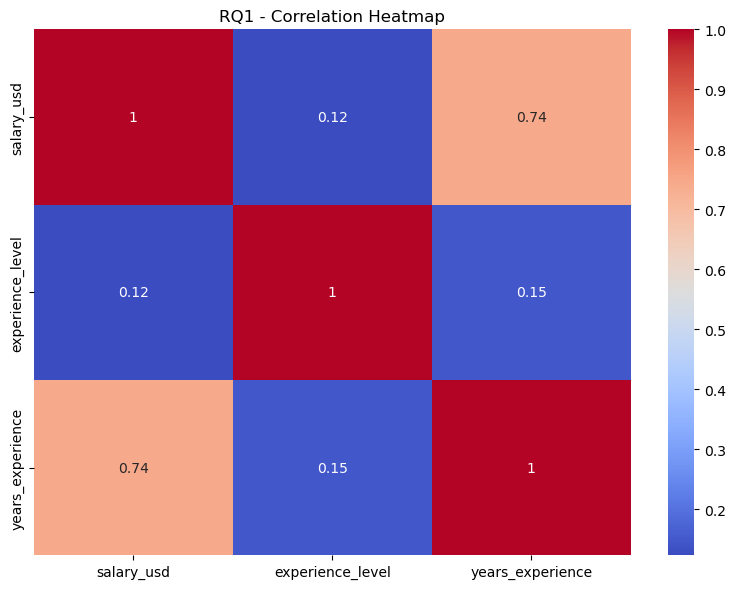

Figure saved in models folder

FINAL CONCLUSION
Best Model: Gradient Boosting
Best R2 Score: 0.6247292018963354

Professional experience strongly
influences salary levels in
AI-related job roles.

All figures saved in 'models' folder
All tables saved in 'tables' folder


In [4]:

# RQ1. How does professional experience influence salary levels in AI-related job roles?




import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)




os.makedirs("models", exist_ok=True)
os.makedirs("tables", exist_ok=True)





df = pd.read_csv("ai_job_dataset1.csv")

print("\nDataset Loaded Successfully")
print(df.head())




selected_columns = [
    'salary_usd',
    'experience_level',
    'years_experience'
]

data = df[selected_columns]


data = data.dropna()

print("\nSelected Data Shape:")
print(data.shape)





sample_data = data.head(100)

sample_data.to_csv(
    'tables/RQ1_sample_dataset.csv',
    index=False
)

print("\nSample dataset saved in tables folder")





encoder = LabelEncoder()

data['experience_level'] = encoder.fit_transform(
    data['experience_level']
)





X = data[[
    'experience_level',
    'years_experience'
]]

y = data['salary_usd']





X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)





models = {

    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    )
}





results = []

best_model = None
best_predictions = None
best_r2 = 0
best_model_name = ""

for name, model in models.items():

   
    model.fit(X_train, y_train)

  
    y_pred = model.predict(X_test)

    
    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

  
    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

    
    print("\n===================================")
    print("Model:", name)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

    
    if r2 > best_r2:

        best_r2 = r2
        best_model = model
        best_predictions = y_pred
        best_model_name = name





results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'MSE',
        'RMSE',
        'R2 Score'
    ]
)

print("\nMODEL COMPARISON RESULTS")
print(results_df)

# Save Results Table
results_df.to_csv(
    'tables/RQ1_model_results.csv',
    index=False
)

print("\nModel results table saved in tables folder")





correlation_table = data.corr()

correlation_table.to_csv(
    'tables/RQ1_correlation_table.csv'
)

print("Correlation table saved in tables folder")





plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results_df
)

plt.title("RQ1 - Model Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("R2 Score")

plt.tight_layout()

plt.savefig(
    'models/RQ1_model_comparison.png'
)

plt.show()

print("Figure saved in models folder")





plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    best_predictions
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title(
    f'RQ1 - Actual vs Predicted ({best_model_name})'
)

plt.tight_layout()

plt.savefig(
    'models/RQ1_actual_vs_predicted.png'
)

plt.show()

print("Figure saved in models folder")





plt.figure(figsize=(10,6))

sns.histplot(
    data['salary_usd'],
    bins=30,
    kde=True
)

plt.title("RQ1 - Salary Distribution")
plt.xlabel("Salary USD")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    'models/RQ1_salary_distribution.png'
)

plt.show()

print("Figure saved in models folder")





plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_table,
    annot=True,
    cmap='coolwarm'
)

plt.title("RQ1 - Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    'models/RQ1_correlation_heatmap.png'
)

plt.show()

print("Figure saved in models folder")





print("\n===================================")
print("FINAL CONCLUSION")
print("===================================")

print("Best Model:", best_model_name)

print("Best R2 Score:", best_r2)

print("\nProfessional experience strongly")
print("influences salary levels in")
print("AI-related job roles.")

print("\nAll figures saved in 'models' folder")
print("All tables saved in 'tables' folder")